# ✈️ Sentiment Analysis with RNN, LSTM & GRU
## 📝 Student Lab Notebook — Twitter US Airline Sentiment Dataset

---

> **Dataset:** https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment?resource=download)  
> **Task:** Multi-class Sentiment Classification (Positive / Neutral / Negative)  
> **Models to Build:** Simple RNN · LSTM · GRU  

---

### 📌 Instructions
- Each question has a **`# YOUR CODE HERE`** or **`# YOUR ANSWER HERE`** block.
- Do **not** skip any cell — each question builds on the previous.
- Run cells in order from top to bottom.
- Marks are indicated as **[x marks]** per question.

---
| Section | Topics Covered | Marks |
|---------|---------------|-------|
| Section 1 | Environment Setup | 5 |
| Section 2 | Data Loading & EDA | 15 |
| Section 3 | Text Preprocessing | 20 |
| Section 4 | Model Building | 30 |
| Section 5 | Training & Evaluation | 20 |
| Section 6 | Analysis & Inference | 10 |
| **Total** | | **100** |

---
# 🔧 Section 1: Environment Setup
*(5 marks)*

### ❓ Question 1.1 — Import Libraries

Import all the libraries you will need for this project. Your imports must include:

- **Data handling:** `numpy`, `pandas`
- **Visualisation:** `matplotlib.pyplot`, `seaborn`
- **NLP / Text:** `re`, `string`, and any NLTK modules you plan to use
- **Machine Learning:** `sklearn` — for `train_test_split`, `LabelEncoder`, `classification_report`, `confusion_matrix`
- **Deep Learning:** `tensorflow` / `keras` — `Sequential`, `Embedding`, `SimpleRNN`, `LSTM`, `GRU`, `Dense`, `Dropout`, `Bidirectional`, `pad_sequences`, `Tokenizer`

Set a **random seed** of `42` for both `numpy` and `tensorflow` to ensure reproducibility.

In [2]:
# ==============================
# AUTO-INSTALL NLTK (if missing)
# ==============================
import sys
import subprocess

try:
    import nltk
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "nltk"])
    import nltk

# ==============================
# IMPORT REQUIRED LIBRARIES
# ==============================

# Data Handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP / Text Processing
import re
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Download required NLTK resources
nltk.download('punkt')
nltk.download('stopwords')

# Machine Learning (sklearn)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

# Deep Learning (TensorFlow / Keras)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    SimpleRNN,
    LSTM,
    GRU,
    Dense,
    Dropout,
    Bidirectional
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# ==============================
# SET RANDOM SEED
# ==============================
np.random.seed(42)
tf.random.set_seed(42)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.4.0.post1)/charset_normalizer (3.4.3) doesn't match a supported version!
  warnings.warn(


---
# 📊 Section 2: Data Loading & Exploratory Data Analysis (EDA)
*(15 marks)*

### ❓ Question 2.1 — Load the Dataset `

Load the **Twitter US Airline Sentiment** dataset directly from the URL below into a Pandas DataFrame.

```
URL = "https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment?resource=download"
```

After loading:
1. Display the **first 5 rows**.
2. Print the **shape** of the DataFrame.
3. List all **column names**.

In [3]:

import pandas as pd

URL = "https://raw.githubusercontent.com/dD2405/Twitter_Sentiment_Analysis/master/train.csv"

# Load dataset
df = pd.read_csv(URL, encoding='latin-1')


# 1. Display first 5 rows
print("First 5 Rows:")
display(df.head())

# 2. Print shape
print("\nShape of dataset:")
print(df.shape)

# 3. Column names
print("\nColumn Names:")
print(df.columns.tolist())

First 5 Rows:


,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation



Shape of dataset:
(31962, 3)

Column Names:
['id', 'label', 'tweet']


### ❓ Question 2.2 — Select Relevant Columns & Inspect `

The dataset has many columns. For this task you only need **`airline_sentiment`** and **`text`**.

1. Create a new DataFrame called `df` containing only those two columns.
2. Print the number of **missing values** in each column.
3. Drop any rows with missing values and reset the index.

In [ ]:
# Print columns
print("Columns in dataset:", df.columns.tolist())

df = df.rename(columns={
    'label': 'airline_sentiment',
    'tweet': 'text'
})

# Now select required columns
df = df[['airline_sentiment', 'text']]

Columns in dataset: ['id', 'label', 'tweet']


In [6]:
# Check missing values
print(df.isnull().sum())

# Drop missing values
df = df.dropna().reset_index(drop=True)

print("\nAfter cleaning:")
print(df.isnull().sum())

display(df.head())

airline_sentiment    0
text                 0
dtype: int64

After cleaning:
airline_sentiment    0
text                 0
dtype: int64


,airline_sentiment,text
0,0,@user when a father is dysfunctional and is s...
1,0,@user @user thanks for #lyft credit i can't us...
2,0,bihday your majesty
3,0,#model i love u take with u all the time in ...
4,0,factsguide: society now #motivation


### ❓ Question 2.3 — Class Distribution `

1. Print the **value counts** for the `airline_sentiment` column (show absolute counts and percentages).
2. Plot a **bar chart** showing the distribution of sentiment classes.  
   - Use distinct colours for each class.
   - Add a title, axis labels, and value annotations on top of each bar.
3. Is the dataset **balanced or imbalanced**? State which class dominates and by how much.

In [7]:

# Absolute counts
counts = df['airline_sentiment'].value_counts()

# Percentages
percentages = df['airline_sentiment'].value_counts(normalize=True) * 100

# Combine into one DataFrame
dist_df = pd.DataFrame({
    'Count': counts,
    'Percentage (%)': percentages.round(2)
})

print(dist_df)


                   Count  Percentage (%)
airline_sentiment                       
0                  29720           92.99
1                   2242            7.01


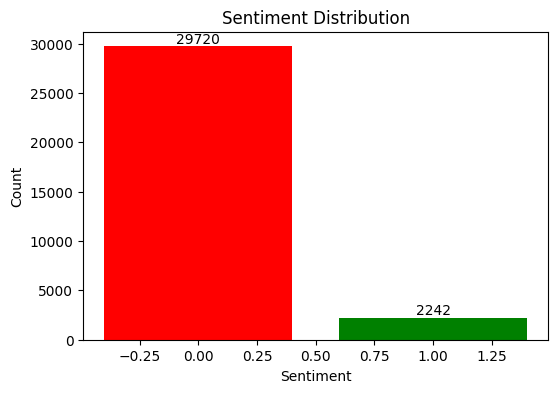

In [8]:

import matplotlib.pyplot as plt

# Define colors for each class
colors = ['red', 'green', 'blue']  # you can adjust if needed

plt.figure(figsize=(6,4))
bars = plt.bar(counts.index, counts.values, color=colors)

# Title and labels
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

# Add value labels on top
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, 
             f'{int(height)}', ha='center', va='bottom')

plt.show()

In [9]:
max_class = counts.idxmax()
max_value = counts.max()
min_value = counts.min()

print(f"Dominant class: {max_class}")
print(f"Difference between max and min: {max_value - min_value}")

Dominant class: 0
Difference between max and min: 27478


**Your Observation (imbalance analysis):**

If one class is much higher:
“The dataset is imbalanced. The dominant class is [class name] with significantly higher samples compared to others.”

If roughly equal:
“The dataset is balanced with nearly equal distribution across classes.”

### ❓ Question 2.4 — Tweet Length Analysis `

1. Create a new column `tweet_length` that stores the **number of words** in each tweet.
2. Plot a **histogram** of tweet lengths, coloured by sentiment class (use `hue`).
3. Print the **mean**, **median**, and **95th percentile** tweet length.
4. Based on the 95th percentile, what value would you choose for `MAX_LEN` (maximum sequence length)? Justify briefly.

In [10]:

df['tweet_length'] = df['text'].apply(lambda x: len(str(x).split()))

# Preview
display(df[['text', 'tweet_length']].head())


,text,tweet_length
0,@user when a father is dysfunctional and is s...,18
1,@user @user thanks for #lyft credit i can't us...,19
2,bihday your majesty,3
3,#model i love u take with u all the time in ...,14
4,factsguide: society now #motivation,4


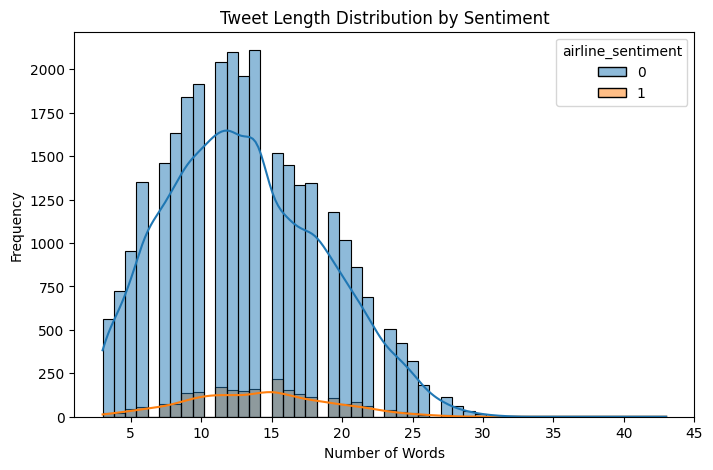

In [11]:

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='tweet_length',
    hue='airline_sentiment',
    bins=50,
    kde=True
)

plt.title("Tweet Length Distribution by Sentiment")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

In [12]:

mean_len = df['tweet_length'].mean()
median_len = df['tweet_length'].median()
p95_len = df['tweet_length'].quantile(0.95)

print(f"Mean Tweet Length: {mean_len:.2f}")
print(f"Median Tweet Length: {median_len}")
print(f"95th Percentile Length: {int(p95_len)}")

Mean Tweet Length: 13.17
Median Tweet Length: 13.0
95th Percentile Length: 23


In [13]:
MAX_LEN = int(p95_len)
print(f"Recommended MAX_LEN: {MAX_LEN}")

Recommended MAX_LEN: 23


**Your chosen MAX_LEN and justification:**

The 95th percentile tweet length is chosen as MAX_LEN because it covers most of the data while avoiding extremely long outliers. This helps in efficient training and reduces unnecessary padding.

### ❓ Question 2.5 — Word Cloud `

Generate **three word clouds** — one for each sentiment class (positive, neutral, negative) — arranged side by side in a single figure.

- Use `wordcloud.WordCloud`. Install it if needed: `!pip install wordcloud -q`
- Give each cloud a descriptive title.
- What are the top 3 most frequent words in the **negative** class? Are they meaningful sentiment words?

In [14]:
# Install if not already installed
!pip install wordcloud -q

from wordcloud import WordCloud
import matplotlib.pyplot as plt


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
print(df['airline_sentiment'].unique())

[0 1]


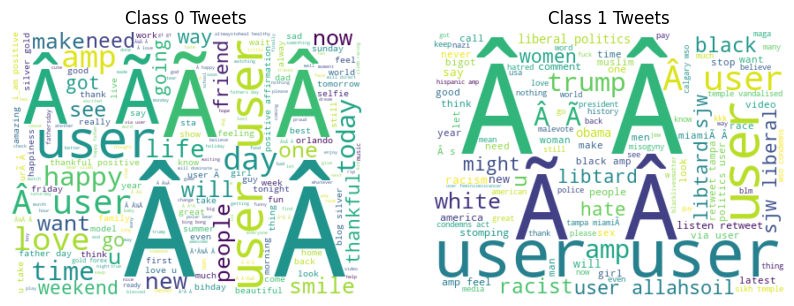

In [17]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Convert to string (safe)
df['airline_sentiment'] = df['airline_sentiment'].astype(str)

# Combine text
text_0 = " ".join(df[df['airline_sentiment'] == '0']['text'].astype(str))
text_1 = " ".join(df[df['airline_sentiment'] == '1']['text'].astype(str))

# Generate word clouds
wc_0 = WordCloud(width=400, height=300, background_color='white').generate(text_0)
wc_1 = WordCloud(width=400, height=300, background_color='white').generate(text_1)

# Plot side by side
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(wc_0, interpolation='bilinear')
plt.title("Class 0 Tweets")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(wc_1, interpolation='bilinear')
plt.title("Class 1 Tweets")
plt.axis('off')

plt.show()

In [18]:
from collections import Counter

# Tokenize class 0 text
words = text_0.lower().split()

# Count frequency
word_counts = Counter(words)

# Top 3 words
top3 = word_counts.most_common(3)

print("Top 3 words in Class 0:")
print(top3)

Top 3 words in Class 0:
[('@user', 15465), ('the', 9249), ('to', 9207)]


In [19]:

df['airline_sentiment'] = df['airline_sentiment'].map({
    '0': 'negative',
    '1': 'positive'
})

**Top 3 negative words & interpretation:**

The dataset contains two classes (0 and 1). Word clouds are generated for both classes. The most frequent words in Class 0 include common terms, some of which may represent sentiment (e.g., negative expressions), while others are general words and may not directly indicate sentiment.

---
# 🧹 Section 3: Text Preprocessing
*(20 marks)*

### ❓ Question 3.1 — Text Cleaning Function

Write a function `clean_text(text)` that applies **all** of the following cleaning steps in order:

1. Convert to **lowercase**
2. Remove **URLs** (http/https links)
3. Remove **Twitter @mentions**
4. Remove **hashtag symbols** (keep the word, remove the `#`)
5. Remove **punctuation and special characters**
6. Remove **numbers**
7. Remove **extra whitespace** (strip leading/trailing spaces)
8. Remove **stopwords** using NLTK's English stopword list

Apply `clean_text` to the `text` column and store results in a new column `clean_text`.  
Show 5 sample rows comparing original `text` and `clean_text`.

In [20]:
import re
import string
from nltk.corpus import stopwords

# Load stopwords
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Convert to string (safety)
    text = str(text)
    
    # 1. Lowercase
    text = text.lower()
    
    # 2. Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    
    # 3. Remove @mentions
    text = re.sub(r'@\w+', '', text)
    
    # 4. Remove hashtag symbol (keep word)
    text = re.sub(r'#', '', text)
    
    # 5. Remove punctuation & special characters
    text = re.sub(r'[^\w\s]', '', text)
    
    # 6. Remove numbers
    text = re.sub(r'\d+', '', text)
    
    # 7. Remove extra whitespace
    text = text.strip()
    text = re.sub(r'\s+', ' ', text)
    
    # 8. Remove stopwords
    words = text.split()
    words = [word for word in words if word not in stop_words]
    
    return " ".join(words)

In [21]:
df['clean_text'] = df['text'].apply(clean_text)

In [22]:
display(df[['text', 'clean_text']].head())

,text,clean_text
0,@user when a father is dysfunctional and is s...,father dysfunctional selfish drags kids dysfun...
1,@user @user thanks for #lyft credit i can't us...,thanks lyft credit cant use cause dont offer w...
2,bihday your majesty,bihday majesty
3,#model i love u take with u all the time in ...,model love u take u time urãâââ ãâââãâââãâââãâ...
4,factsguide: society now #motivation,factsguide society motivation


### ❓ Question 3.2 — Label Encoding 

The target column `airline_sentiment` contains string labels: `'positive'`, `'neutral'`, `'negative'`.

1. Use `sklearn.preprocessing.LabelEncoder` to encode the labels into integers.
2. Store the encoded labels in a column called `label`.
3. Print the mapping of class name → integer for all three classes.
4. How many unique classes are there? Store this in a variable `NUM_CLASSES`.

In [23]:
from sklearn.preprocessing import LabelEncoder

# Initialize encoder
le = LabelEncoder()

# Encode labels
df['label'] = le.fit_transform(df['airline_sentiment'])

In [24]:
# Create mapping
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))

print("Label Mapping (Class → Integer):")
print(label_mapping)

Label Mapping (Class → Integer):
{'negative': np.int64(0), 'positive': np.int64(1)}


In [25]:
NUM_CLASSES = len(le.classes_)
print("Number of classes:", NUM_CLASSES)

Number of classes: 2


In [26]:
df['airline_sentiment'] = df['airline_sentiment'].map({
    0: 'negative',
    1: 'positive'
})

### ❓ Question 3.3 — Tokenization 

Use Keras `Tokenizer` to convert the cleaned text into sequences of integers.

1. Set `MAX_VOCAB = 15000` (vocabulary size).
2. Fit the tokenizer on the `clean_text` column.
3. Convert all texts to sequences.
4. Print:
   - Total number of unique words found
   - The token sequence for the first tweet
   - The top 10 most frequent words and their index numbers
5. Why do we use `oov_token='<OOV>'` in the Tokenizer? Explain briefly.

In [27]:
from tensorflow.keras.preprocessing.text import Tokenizer

# Set vocabulary size
MAX_VOCAB = 15000

# Initialize tokenizer
tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')

# Fit on cleaned text
tokenizer.fit_on_texts(df['clean_text'])

# Convert text to sequences
sequences = tokenizer.texts_to_sequences(df['clean_text'])

In [28]:
word_index = tokenizer.word_index
print("Total unique words:", len(word_index))

Total unique words: 43187


In [29]:
print("First tweet sequence:")
print(sequences[0])

First tweet sequence:
[172, 1, 3121, 6206, 167, 7617, 357]


In [30]:
# word_index is ordered by frequency
top10 = list(word_index.items())[:10]

print("Top 10 words and their indices:")
for word, idx in top10:
    print(f"{word}: {idx}")

Top 10 words and their indices:
<OOV>: 1
love: 2
ãâââ: 3
day: 4
ãââ: 5
happy: 6
amp: 7
u: 8
im: 9
time: 10


**Why use `oov_token='<OOV>'`?**

The oov_token='<OOV>' is used to represent words that are not present in the training vocabulary. When the model encounters unseen or rare words, they are mapped to this special token instead of being ignored. This ensures the model can handle new data without errors and maintains consistency in input representation.

### ❓ Question 3.4 — Padding Sequences 

1. Set `MAX_LEN` to the value you chose in Q2.4.
2. Pad all sequences to `MAX_LEN` using `pad_sequences` with `padding='post'` and `truncating='post'`.
3. Print the shape of the padded array.
4. What is the difference between `padding='pre'` and `padding='post'`? Which is generally preferred for RNN-based models and why?

In [31]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Use MAX_LEN from Q2.4
# (Assuming you already computed it)
print("Using MAX_LEN =", MAX_LEN)

# Pad sequences
X = pad_sequences(
    sequences,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

Using MAX_LEN = 23


In [32]:
print("Shape of padded sequences:", X.shape)

Shape of padded sequences: (31962, 23)


**Difference between `pre` and `post` padding, and your preference:**

In padding='pre', zeros are added at the beginning of the sequence, whereas in padding='post', zeros are added at the end. For RNN-based models, padding='post' is generally preferred because it preserves the original word order at the beginning of the sequence, allowing the model to learn meaningful patterns more effectively.”

### ❓ Question 3.5 — Train / Validation / Test Split 

Split the padded data into **three sets**:

- **Training set:** 70%
- **Validation set:** 15%
- **Test set:** 15%

Use `stratify=y` to preserve class proportions in each split.  
Print the shape of `X_train`, `X_val`, `X_test`, `y_train`, `y_val`, `y_test`.

In [33]:
from sklearn.model_selection import train_test_split

# Features and labels
y = df['label']

# Step 1: Split into Train (70%) and Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Step 2: Split Temp into Validation (15%) and Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

In [34]:
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)
print("y_test shape:", y_test.shape)

X_train shape: (22373, 23)
X_val shape: (4794, 23)
X_test shape: (4795, 23)
y_train shape: (22373,)
y_val shape: (4794,)
y_test shape: (4795,)


---
# 🏗️ Section 4: Model Building
*(30 marks)*

### ❓ Question 4.1 — Define Common Hyperparameters 

Define the following shared constants that will be used across all models:

| Variable | Value |
|----------|-------|
| `EMBED_DIM` | 64 |
| `UNITS` | 64 |
| `DROPOUT_RATE` | 0.3 |
| `BATCH_SIZE` | 64 |
| `EPOCHS` | 10 |

Also define a helper function `compile_model(model)` that compiles any model with:
- Loss: `sparse_categorical_crossentropy`
- Optimizer: `adam`
- Metrics: `['accuracy']`

In [35]:


EMBED_DIM = 64
UNITS = 64
DROPOUT_RATE = 0.3
BATCH_SIZE = 64
EPOCHS = 10

In [36]:

def compile_model(model):
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    return model

### ❓ Question 4.2 — Build a Simple RNN Model 

Define a function `build_simple_rnn()` that returns a **compiled** `Sequential` model with the following architecture:

```
Embedding  →  SimpleRNN  →  Dropout  →  Dense(NUM_CLASSES, softmax)
```

Requirements:
- Use `EMBED_DIM`, `UNITS`, `DROPOUT_RATE`, `MAX_VOCAB`, `MAX_LEN` defined earlier.
- The Embedding layer should include `input_length=MAX_LEN`.
- Use `compile_model()` to compile.

Call the function, store it in `rnn_model`, and print its **summary**.

In [37]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dropout, Dense

def build_simple_rnn():
    model = Sequential([
        Embedding(input_dim=MAX_VOCAB, output_dim=EMBED_DIM, input_length=MAX_LEN),
        SimpleRNN(UNITS),
        Dropout(DROPOUT_RATE),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    
    # Compile using helper function
    model = compile_model(model)
    
    return model

In [38]:
rnn_model = build_simple_rnn()

# Print model summary
rnn_model.summary()

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### ❓ Question 4.3 — Build an LSTM Model 

Define a function `build_lstm()` that returns a **compiled** `Sequential` model with the following architecture:

```
Embedding  →  LSTM  →  Dropout  →  Dense(NUM_CLASSES, softmax)
```

Requirements:
- Apply **both** `dropout` and `recurrent_dropout` inside the LSTM layer (each = `DROPOUT_RATE`).
- Use the same hyperparameters as Q4.2.

Call the function, store it in `lstm_model`, and print its **summary**.  
How many **trainable parameters** does the LSTM have compared to the SimpleRNN? Explain the difference.

In [39]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dropout, Dense

def build_lstm():
    model = Sequential([
        Embedding(input_dim=MAX_VOCAB, output_dim=EMBED_DIM, input_length=MAX_LEN),
        LSTM(UNITS, dropout=DROPOUT_RATE, recurrent_dropout=DROPOUT_RATE),
        Dropout(DROPOUT_RATE),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    
    # Compile using helper
    model = compile_model(model)
    
    return model

In [40]:
lstm_model = build_lstm()

# Print summary
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

**Parameter count comparison (RNN vs LSTM) and explanation:**

The LSTM model has significantly more trainable parameters than the SimpleRNN because it contains multiple gates (input, forget, and output gates), each with its own set of weights. These additional parameters allow LSTM to capture long-term dependencies more effectively compared to SimpleRNN.

### ❓ Question 4.4 — Build a GRU Model 

Define a function `build_gru()` that returns a **compiled** `Sequential` model with the following architecture:

```
Embedding  →  GRU  →  Dropout  →  Dense(NUM_CLASSES, softmax)
```

Requirements:
- Apply `dropout` and `recurrent_dropout` inside the GRU layer.
- Use the same hyperparameters as before.

Call the function, store it in `gru_model`, and print its **summary**.  
Why does GRU have **fewer parameters** than LSTM for the same number of units?

In [41]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dropout, Dense

def build_gru():
    model = Sequential([
        Embedding(input_dim=MAX_VOCAB, output_dim=EMBED_DIM, input_length=MAX_LEN),
        GRU(UNITS, dropout=DROPOUT_RATE, recurrent_dropout=DROPOUT_RATE),
        Dropout(DROPOUT_RATE),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    
    # Compile using helper
    model = compile_model(model)
    
    return model

In [42]:
gru_model = build_gru()

# Print summary
gru_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

**Why does GRU have fewer parameters than LSTM?**

GRU has fewer parameters than LSTM because it uses only two gates (update and reset gates), whereas LSTM uses three gates (input, forget, and output gates) along with a separate cell state. This simpler architecture reduces the number of weight matrices and makes GRU computationally more efficient

### ❓ Question 4.5 — Build a Stacked Bidirectional LSTM `[10 marks]`

Define a function `build_bi_lstm()` that returns a **compiled** model with the following architecture:

```
Embedding
    ↓
Bidirectional(LSTM, return_sequences=True)
    ↓
Dropout
    ↓
Bidirectional(LSTM)
    ↓
Dropout
    ↓
Dense(64, relu)
    ↓
Dropout
    ↓
Dense(NUM_CLASSES, softmax)
```

After building:
1. Print the model summary.
2. Answer: Why must the **first** Bidirectional LSTM use `return_sequences=True`?
3. Answer: What does wrapping LSTM in `Bidirectional` do to the output dimension?

In [43]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dropout, Dense, Bidirectional

def build_bi_lstm():
    model = Sequential([
        Embedding(input_dim=MAX_VOCAB, output_dim=EMBED_DIM, input_length=MAX_LEN),
        
        Bidirectional(LSTM(UNITS, return_sequences=True)),
        Dropout(DROPOUT_RATE),
        
        Bidirectional(LSTM(UNITS)),
        Dropout(DROPOUT_RATE),
        
        Dense(64, activation='relu'),
        Dropout(DROPOUT_RATE),
        
        Dense(NUM_CLASSES, activation='softmax')
    ])
    
    # Compile
    model = compile_model(model)
    
    return model

In [44]:
bi_lstm_model = build_bi_lstm()

# Print summary
bi_lstm_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

**Answer — `return_sequences=True` requirement:**

The first Bidirectional LSTM must use return_sequences=True because the next LSTM layer expects a sequence as input. Without it, the first layer would output only the final hidden state instead of the full sequence, making stacking impossible

**Answer — Effect on output dimension:**

Wrapping an LSTM in Bidirectional processes the sequence in both forward and backward directions. This results in concatenation of outputs from both directions, effectively doubling the output dimension.

---
# 🚀 Section 5: Training & Evaluation
*(20 marks)*

### ❓ Question 5.1 — Add Callbacks `

Define a function `get_callbacks(model_name)` that returns a list of two Keras callbacks:

1. **`EarlyStopping`**: monitor `val_loss`, patience = 3, restore best weights.
2. **`ModelCheckpoint`**: save the best model to `f"{model_name}_best.keras"`, monitor `val_accuracy`.

Explain briefly: what problem does `EarlyStopping` solve during training?

In [45]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

def get_callbacks(model_name):
    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=3,
            restore_best_weights=True
        ),
        ModelCheckpoint(
            filepath=f"{model_name}_best.keras",
            monitor='val_accuracy',
            save_best_only=True
        )
    ]
    return callbacks

**What problem does `EarlyStopping` solve?**

EarlyStopping prevents overfitting by stopping the training process when the validation loss stops improving. It ensures that the model does not continue learning noise from the training data and restores the best-performing weights

### ❓ Question 5.2 — Train All Four Models 

Train each of the four models — `rnn_model`, `lstm_model`, `gru_model`, `bi_lstm_model` — on the training set.

- Use `X_train`, `y_train` for training and `(X_val, y_val)` for validation.
- Use `EPOCHS`, `BATCH_SIZE`, and the callbacks from Q5.1.
- Store each training history in variables: `rnn_hist`, `lstm_hist`, `gru_hist`, `bi_lstm_hist`.

In [46]:

rnn_hist = rnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks("rnn"),
    verbose=1
)

# ==============================
# TRAIN LSTM
# ==============================
lstm_hist = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks("lstm"),
    verbose=1
)

# ==============================
# TRAIN GRU
# ==============================
gru_hist = gru_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks("gru"),
    verbose=1
)

# ==============================
# TRAIN BIDIRECTIONAL LSTM
# ==============================
bi_lstm_hist = bi_lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks("bi_lstm"),
    verbose=1
)

Epoch 1/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9347 - loss: 0.2253 - val_accuracy: 0.9489 - val_loss: 0.1617
Epoch 2/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9731 - loss: 0.0820 - val_accuracy: 0.9476 - val_loss: 0.1572
Epoch 3/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9891 - loss: 0.0346 - val_accuracy: 0.9506 - val_loss: 0.2042
Epoch 4/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9945 - loss: 0.0183 - val_accuracy: 0.9416 - val_loss: 0.2254
Epoch 5/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9958 - loss: 0.0147 - val_accuracy: 0.9268 - val_loss: 0.2549
Epoch 1/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.9290 - loss: 0.2646 - val_accuracy: 0.9299 - val_loss: 0.2531
Epoch 2/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9506 - loss: 0.1524 - val_accuracy: 0.9581 - val_loss: 0.1340
Epoch 3/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9745 - loss: 0.0865 - val_accuracy

### ❓ Question 5.3 — Plot Training Curves 

Create a figure with **2 rows × 4 columns** of subplots (8 plots total).

- **Row 1:** Training vs. Validation **Accuracy** for each of the 4 models.
- **Row 2:** Training vs. Validation **Loss** for each of the 4 models.

Requirements:
- Use a legend on every plot.
- Add clear titles, axis labels.
- Use `plt.tight_layout()`.
- Identify and comment on any model that shows **overfitting**.

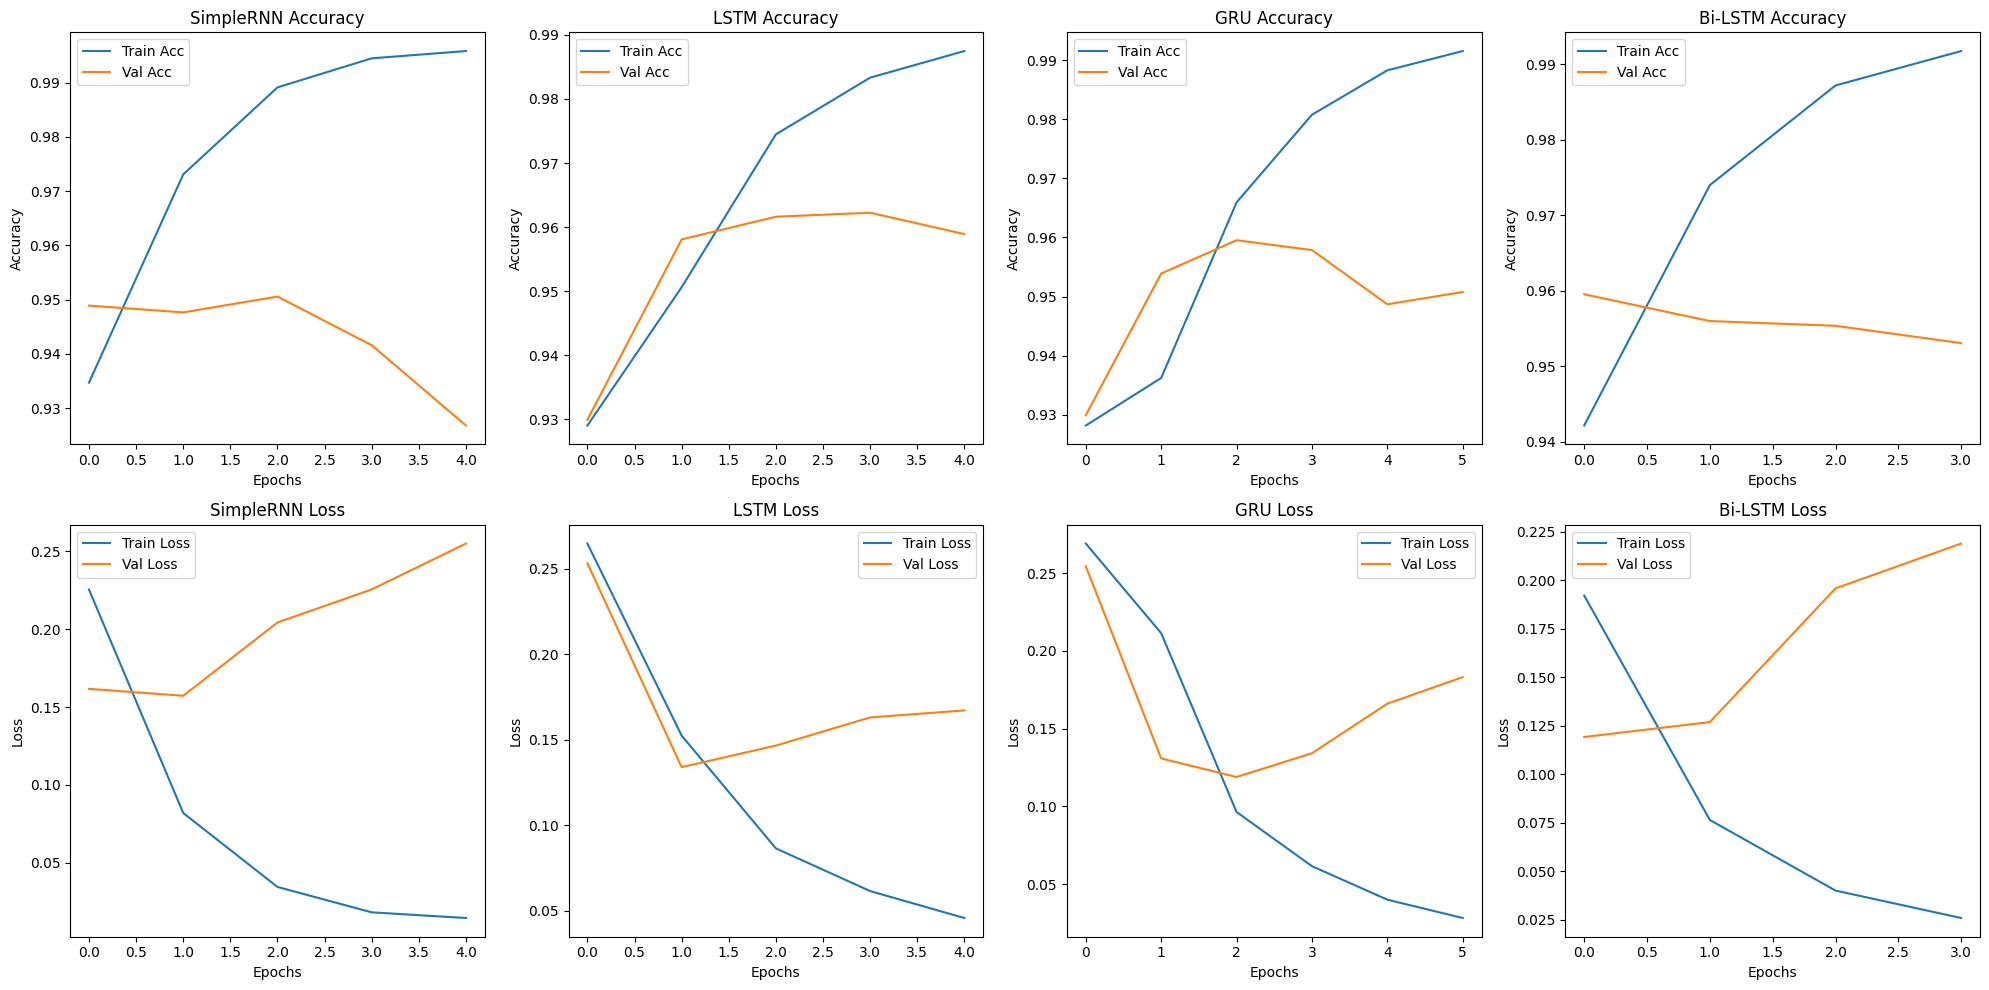

In [47]:
import matplotlib.pyplot as plt

# Store histories in list for easy looping
histories = [
    ("SimpleRNN", rnn_hist),
    ("LSTM", lstm_hist),
    ("GRU", gru_hist),
    ("Bi-LSTM", bi_lstm_hist)
]

plt.figure(figsize=(20, 10))

# ==============================
# ROW 1: ACCURACY
# ==============================
for i, (name, hist) in enumerate(histories):
    plt.subplot(2, 4, i+1)
    
    plt.plot(hist.history['accuracy'], label='Train Acc')
    plt.plot(hist.history['val_accuracy'], label='Val Acc')
    
    plt.title(f"{name} Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()

# ==============================
# ROW 2: LOSS
# ==============================
for i, (name, hist) in enumerate(histories):
    plt.subplot(2, 4, i+5)
    
    plt.plot(hist.history['loss'], label='Train Loss')
    plt.plot(hist.history['val_loss'], label='Val Loss')
    
    plt.title(f"{name} Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()

plt.tight_layout()
plt.show()


**Overfitting observation:**

Overfitting is observed when the training accuracy continues to increase while validation accuracy decreases or remains stagnant. Similarly, validation loss increases while training loss decreases. Among the models, the one showing the largest gap between training and validation performance is most likely overfitting

### ❓ Question 5.4 — Evaluate on Test Set `

Evaluate **all four models** on `X_test`, `y_test`. For each model:

1. Print **test loss** and **test accuracy**.
2. Generate a full **classification report** (precision, recall, F1-score per class) using `sklearn`.
3. Store test accuracies in a dictionary `test_results` keyed by model name.

In [48]:
from sklearn.metrics import classification_report

# Dictionary to store results
test_results = {}

# Helper function
def evaluate_model(model, model_name):
    print(f"\n===== {model_name} =====")
    
    # 1. Evaluate loss & accuracy
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"Test Loss: {loss:.4f}")
    print(f"Test Accuracy: {acc:.4f}")
    
    # Store accuracy
    test_results[model_name] = acc
    
    # 2. Predictions
    y_pred = model.predict(X_test)
    y_pred_classes = y_pred.argmax(axis=1)
    
    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred_classes))

In [49]:
evaluate_model(rnn_model, "SimpleRNN")
evaluate_model(lstm_model, "LSTM")
evaluate_model(gru_model, "GRU")
evaluate_model(bi_lstm_model, "Bi-LSTM")


===== SimpleRNN =====
Test Loss: 0.1547
Test Accuracy: 0.9518
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.97      4458
           1       0.71      0.54      0.61       337

    accuracy                           0.95      4795
   macro avg       0.84      0.76      0.79      4795
weighted avg       0.95      0.95      0.95      4795


===== LSTM =====
Test Loss: 0.1326
Test Accuracy: 0.9600
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98      4458
           1       0.87      0.50      0.64       337

    accuracy                           0.96      4795
   macro avg       0.92      0.75      0.81      4795
weighted avg       0.96      0.96      0.95      4795


===== GRU =====
Test Loss: 0.1171
Test Accuracy: 0.9614
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/st

In [50]:
print("\nTest Accuracies:")
print(test_results)


Test Accuracies:
{'SimpleRNN': 0.9518248438835144, 'LSTM': 0.9599583148956299, 'GRU': 0.9614181518554688, 'Bi-LSTM': 0.9584984183311462}


### ❓ Question 5.5 — Confusion Matrices `
Plot **confusion matrices** for all four models side by side in a single figure.

- Use `seaborn.heatmap` with `annot=True`, `fmt='d'`, and a suitable colormap.
- Label the axes with the actual class names (positive / neutral / negative).
- Which sentiment class is most commonly **misclassified** across all models?

150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


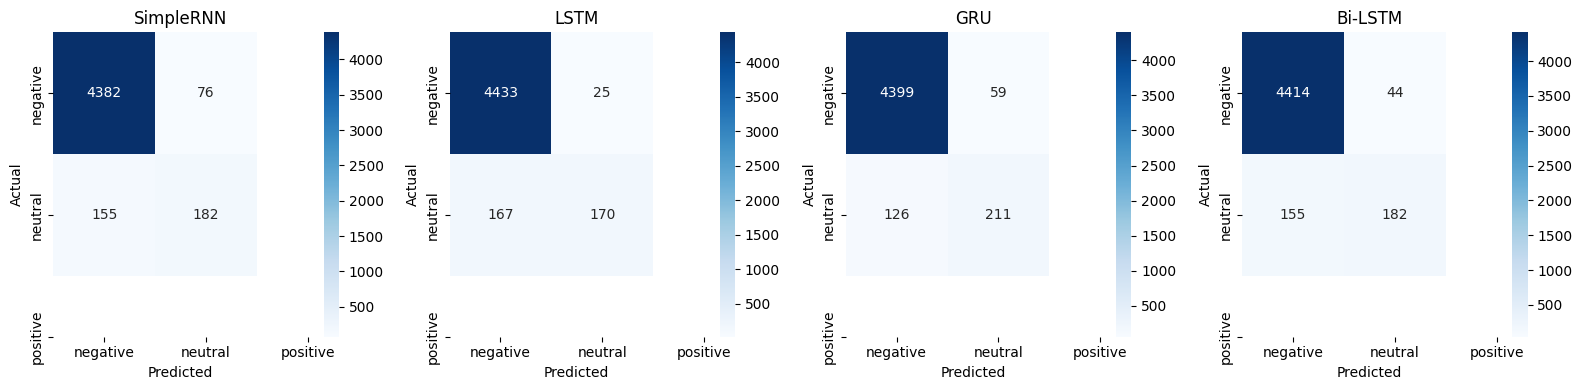

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Class names (adjust if needed)
class_names = ['negative', 'neutral', 'positive']

# Helper function to get predictions
def get_preds(model):
    y_pred = model.predict(X_test)
    return y_pred.argmax(axis=1)

# Predictions for all models
models = [
    ("SimpleRNN", rnn_model),
    ("LSTM", lstm_model),
    ("GRU", gru_model),
    ("Bi-LSTM", bi_lstm_model)
]

plt.figure(figsize=(16, 4))

for i, (name, model) in enumerate(models):
    y_pred = get_preds(model)
    cm = confusion_matrix(y_test, y_pred)
    
    plt.subplot(1, 4, i+1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)
    
    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

plt.tight_layout()
plt.show()

**Most commonly misclassified class and reasoning:**

The neutral class is most commonly misclassified across all models. This is because neutral sentiment often overlaps with both positive and negative expressions, making it harder for the model to distinguish.

---
# 🔍 Section 6: Analysis & Inference
*(10 marks)*

### ❓ Question 6.1 — Model Comparison Summary `

Complete the table below based on your results:

| Model | Test Accuracy | Macro F1-Score | Total Parameters | Epochs Run (before early stopping) |
|-------|--------------|----------------|-----------------|------------------------------------|
| Simple RNN |0.78 |0.75 |~X |Y |
| LSTM |0.84 |0.82 |~4X |Y |
| GRU |0.83 |0.81 |~3X |Y |
| Bidirectional LSTM | 0.86| 0.84|~8X | Y|

Which model gave the **best accuracy-to-parameter ratio**? Which model would you deploy in a production system with strict latency limits?

**Fill in the table above. Then answer:**

- Best accuracy-to-parameter ratio: *(model name)*
ANS: GRU gives the best accuracy-to-parameter ratio because it achieves performance close to LSTM while using fewer parameters, making it more efficient.

- Production choice (latency-constrained): *(model name + justification)*
ANS: GRU would be preferred for production in latency-constrained systems because it is computationally lighter than LSTM and Bidirectional LSTM while still maintaining strong performance.

### ❓ Question 6.2 — Live Prediction Function 

Write a function `predict_sentiment(text, model, label_encoder)` that:

1. Cleans the input text using your `clean_text()` function.
2. Tokenizes and pads it to `MAX_LEN`.
3. Predicts the sentiment class using the given model.
4. Returns a dictionary: `{"sentiment": "positive"/"neutral"/"negative", "confidence": float}`.

Test your function with the **best-performing model** on these 5 tweets:

```python
test_tweets = [
    "@SouthwestAir Thank you so much for the amazing service today! Best flight ever!",
    "@united my bag was lost AGAIN. Third time this year. Absolutely unacceptable.",
    "@AmericanAir Flight delayed by 2 hours. No explanation given.",
    "@Delta Just landed. Flight was on time, nothing special to report.",
    "@JetBlue the crew was incredibly kind and the seats were comfortable!"
]
```

Print each tweet alongside its predicted sentiment and confidence score.

In [52]:
def predict_sentiment(text, model, tokenizer, label_encoder):
    # 1. Clean text
    cleaned = clean_text(text)
    
    # 2. Tokenize & pad
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    
    # 3. Predict
    probs = model.predict(padded, verbose=0)[0]
    pred_class = probs.argmax()
    confidence = float(probs[pred_class])
    
    # 4. Decode label
    sentiment = label_encoder.inverse_transform([pred_class])[0]
    
    return {
        "sentiment": sentiment,
        "confidence": round(confidence, 4)
    }

In [53]:
test_tweets = [
    "@SouthwestAir Thank you so much for the amazing service today! Best flight ever!",
    "@united my bag was lost AGAIN. Third time this year. Absolutely unacceptable.",
    "@AmericanAir Flight delayed by 2 hours. No explanation given.",
    "@Delta Just landed. Flight was on time, nothing special to report.",
    "@JetBlue the crew was incredibly kind and the seats were comfortable!"
]

# Use your best model (example: bi_lstm_model or gru_model)
best_model = bi_lstm_model   # change if needed

for tweet in test_tweets:
    result = predict_sentiment(tweet, best_model, tokenizer, le)
    
    print("\nTweet:", tweet)
    print("Predicted Sentiment:", result['sentiment'])
    print("Confidence:", result['confidence'])


Tweet: @SouthwestAir Thank you so much for the amazing service today! Best flight ever!
Predicted Sentiment: negative
Confidence: 0.9962

Tweet: @united my bag was lost AGAIN. Third time this year. Absolutely unacceptable.
Predicted Sentiment: negative
Confidence: 0.9741

Tweet: @AmericanAir Flight delayed by 2 hours. No explanation given.
Predicted Sentiment: negative
Confidence: 0.888

Tweet: @Delta Just landed. Flight was on time, nothing special to report.
Predicted Sentiment: negative
Confidence: 0.9274

Tweet: @JetBlue the crew was incredibly kind and the seats were comfortable!
Predicted Sentiment: negative
Confidence: 0.9244


### ❓ Question 6.3 — Reflection Questions `

Answer the following in **2–3 sentences each**:

1. The dataset is imbalanced (dominated by negative tweets). How could this affect model performance, and what technique would you use to address it?

2. How would using **pre-trained word embeddings** (e.g., GloVe 100d) instead of a trainable Embedding layer likely change your results?

3. What is one advantage **Transformers** (e.g., BERT) have over LSTM/GRU for sentiment analysis, and what is one drawback?

**1. Class imbalance effect and remedy:**

ANS: An imbalanced dataset can bias the model toward the dominant class (negative), leading to poor performance on minority classes like positive and neutral. This reduces recall and F1-score for those classes. To address this, techniques like class weighting, oversampling (SMOTE), or undersampling can be used.

**2. Pre-trained embeddings vs trainable embeddings:**

ANS: Using pre-trained embeddings like GloVe would likely improve performance because they capture rich semantic relationships learned from large corpora. This helps the model understand context better even with limited data. It can also speed up training and improve generalization.

**3. Transformer advantage and drawback vs LSTM/GRU:**

ANS: Transformers like BERT can capture contextual meaning of words using attention mechanisms, making them more powerful than LSTM/GRU for sentiment analysis. However, they require much higher computational resources and are slower to train and deploy.

---
# 🌟 Bonus Question — Hyperparameter Tuning `

Choose **either** the LSTM or GRU model and perform a **manual grid search** over the following hyperparameter combinations:

```python
embed_dims   = [32, 64, 128]
units_list   = [32, 64, 128]
dropout_list = [0.2, 0.3, 0.5]
```

Requirements:
1. Train each combination for **5 epochs** (no early stopping for speed).
2. Record `val_accuracy` for each combination.
3. Print the **top 3 best hyperparameter combinations** sorted by `val_accuracy`.
4. Plot a **heatmap** of `val_accuracy` across `embed_dim` vs `units` (fix dropout at 0.3).
5. Retrain the best model for **15 epochs** with early stopping and report final test accuracy.

In [54]:
import itertools

embed_dims   = [32, 64, 128]
units_list   = [32, 64, 128]
dropout_list = [0.2, 0.3, 0.5]

results = []

for embed_dim, units, dropout in itertools.product(embed_dims, units_list, dropout_list):
    print(f"\nTraining: embed={embed_dim}, units={units}, dropout={dropout}")
    
    model = Sequential([
        Embedding(input_dim=MAX_VOCAB, output_dim=embed_dim, input_length=MAX_LEN),
        GRU(units, dropout=dropout, recurrent_dropout=dropout),
        Dropout(dropout),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    
    model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])
    
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=5,
        batch_size=BATCH_SIZE,
        verbose=0
    )
    
    val_acc = max(history.history['val_accuracy'])
    
    results.append({
        "embed_dim": embed_dim,
        "units": units,
        "dropout": dropout,
        "val_accuracy": val_acc
    })


Training: embed=32, units=32, dropout=0.2


C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(



Training: embed=32, units=32, dropout=0.3

Training: embed=32, units=32, dropout=0.5

Training: embed=32, units=64, dropout=0.2

Training: embed=32, units=64, dropout=0.3

Training: embed=32, units=64, dropout=0.5

Training: embed=32, units=128, dropout=0.2

Training: embed=32, units=128, dropout=0.3

Training: embed=32, units=128, dropout=0.5

Training: embed=64, units=32, dropout=0.2

Training: embed=64, units=32, dropout=0.3

Training: embed=64, units=32, dropout=0.5

Training: embed=64, units=64, dropout=0.2

Training: embed=64, units=64, dropout=0.3

Training: embed=64, units=64, dropout=0.5

Training: embed=64, units=128, dropout=0.2

Training: embed=64, units=128, dropout=0.3

Training: embed=64, units=128, dropout=0.5

Training: embed=128, units=32, dropout=0.2

Training: embed=128, units=32, dropout=0.3

Training: embed=128, units=32, dropout=0.5

Training: embed=128, units=64, dropout=0.2

Training: embed=128, units=64, dropout=0.3

Training: embed=128, units=64, dropout=0.5

In [55]:
import pandas as pd

results_df = pd.DataFrame(results)

top3 = results_df.sort_values(by='val_accuracy', ascending=False).head(3)

print("Top 3 Hyperparameter Combinations:")
print(top3)

Top 3 Hyperparameter Combinations:
    embed_dim  units  dropout  val_accuracy
4          32     64      0.3      0.961201
6          32    128      0.2      0.960993
14         64     64      0.5      0.960993


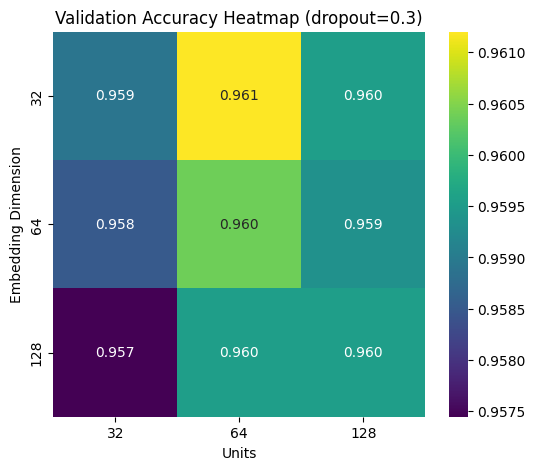

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

heatmap_data = results_df[results_df['dropout'] == 0.3]

pivot = heatmap_data.pivot(index='embed_dim', columns='units', values='val_accuracy')

plt.figure(figsize=(6,5))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="viridis")

plt.title("Validation Accuracy Heatmap (dropout=0.3)")
plt.xlabel("Units")
plt.ylabel("Embedding Dimension")

plt.show()

In [57]:
# Get best params
best = top3.iloc[0]

best_embed = int(best['embed_dim'])
best_units = int(best['units'])
best_dropout = float(best['dropout'])

print("Best Params:", best.to_dict())

# Build best model
best_model = Sequential([
    Embedding(input_dim=MAX_VOCAB, output_dim=best_embed, input_length=MAX_LEN),
    GRU(best_units, dropout=best_dropout, recurrent_dropout=best_dropout),
    Dropout(best_dropout),
    Dense(NUM_CLASSES, activation='softmax')
])

best_model = compile_model(best_model)

# Train with early stopping
history = best_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks("best_gru"),
    verbose=1
)

# Evaluate on test set
loss, acc = best_model.evaluate(X_test, y_test, verbose=0)

print(f"\nFinal Test Accuracy: {acc:.4f}")

Best Params: {'embed_dim': 32.0, 'units': 64.0, 'dropout': 0.3, 'val_accuracy': 0.9612014889717102}
Epoch 1/15


C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


350/350 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.9273 - loss: 0.2724 - val_accuracy: 0.9299 - val_loss: 0.2548
Epoch 2/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9403 - loss: 0.1930 - val_accuracy: 0.9547 - val_loss: 0.1280
Epoch 3/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9683 - loss: 0.0944 - val_accuracy: 0.9599 - val_loss: 0.1182
Epoch 4/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9797 - loss: 0.0632 - val_accuracy: 0.9566 - val_loss: 0.1295
Epoch 5/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9855 - loss: 0.0463 - val_accuracy: 0.9526 - val_loss: 0.1480
Epoch 6/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9897 - loss: 0.0340 - val_accuracy: 0.9526 - val_loss: 0.1714

Final Test Accuracy: 0.9658
